# Uber Ride Analytics & Demand Forecasting System

## Data Understanding & Exploratory Data Analysis

This project focuses on analyzing ride booking patterns, identifying operational trends, forecasting future ride demand, and building business intelligence dashboards using machine learning and Power BI.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
print("Libraries imported successfully")

Libraries imported successfully


## Dataset Loading

The ride booking dataset is loaded into a Pandas DataFrame for preprocessing and analysis.

In [2]:
df = pd.read_csv("/content/ncr_ride_bookings.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Initial Data Inspection

In this step, the dataset structure, shape, columns, and sample records are inspected to understand the available business and operational information.

In [6]:
print("Dataset Shape:")
print(df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape:
(49294, 21)

Columns:
Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

First 5 Rows:


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


## Dataset Information

This step checks:
- data types
- null values
- column structure
- memory usage

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49294 entries, 0 to 49293
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               49294 non-null  object 
 1   Time                               49294 non-null  object 
 2   Booking ID                         49294 non-null  object 
 3   Booking Status                     49294 non-null  object 
 4   Customer ID                        49294 non-null  object 
 5   Vehicle Type                       49294 non-null  object 
 6   Pickup Location                    49294 non-null  object 
 7   Drop Location                      49294 non-null  object 
 8   Avg VTAT                           45806 non-null  float64
 9   Avg CTAT                           33565 non-null  float64
 10  Cancelled Rides by Customer        3462 non-null   float64
 11  Reason for cancelling by Customer  3462 non-null   obj

In [5]:
missing_values = df.isnull().sum()
missing_values

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,3488
Avg CTAT,15729


In [7]:
duplicates = df.duplicated().sum()
print("Total Duplicate Rows:", duplicates)

Total Duplicate Rows: 0


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time
print("Date and Time converted successfully")

Date and Time converted successfully


## Feature Engineering

New time-based features are created to support trend analysis, forecasting, and machine learning.

In [9]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()
print("Feature engineering completed")

Feature engineering completed


In [10]:
df['Hour'] = pd.to_datetime(
    df['Time'].astype(str)
).dt.hour
df[['Time', 'Hour']].head()

/tmp/ipykernel_1221/671490584.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(


,Time,Hour
0,12:29:38,12
1,18:01:39,18
2,08:56:10,8
3,17:17:25,17
4,22:08:00,22


## Booking Status Distribution

This analysis shows the distribution of completed, cancelled, and incomplete rides.

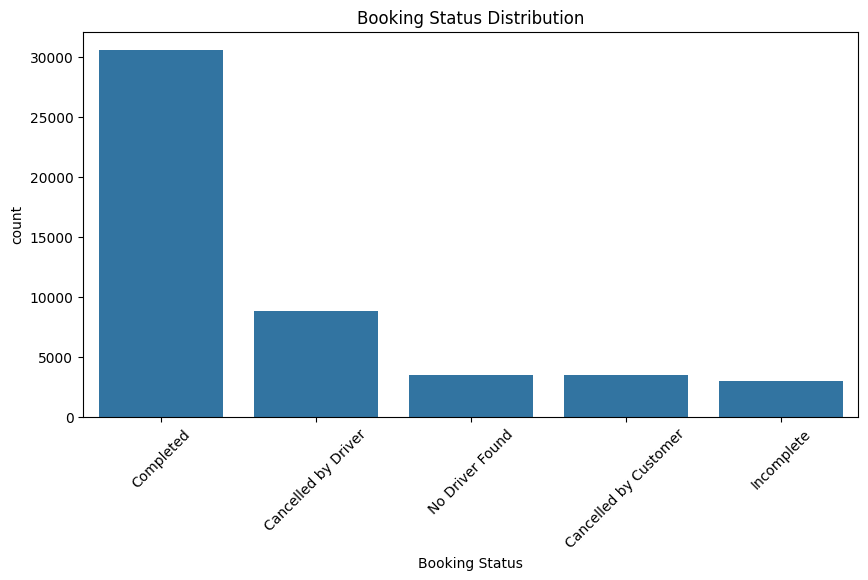

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Booking Status',
    data=df,
    order=df['Booking Status'].value_counts().index
)
plt.xticks(rotation=45)
plt.title("Booking Status Distribution")
plt.show()

## Booking Revenue Analysis

This visualization analyzes ride booking revenue distribution.

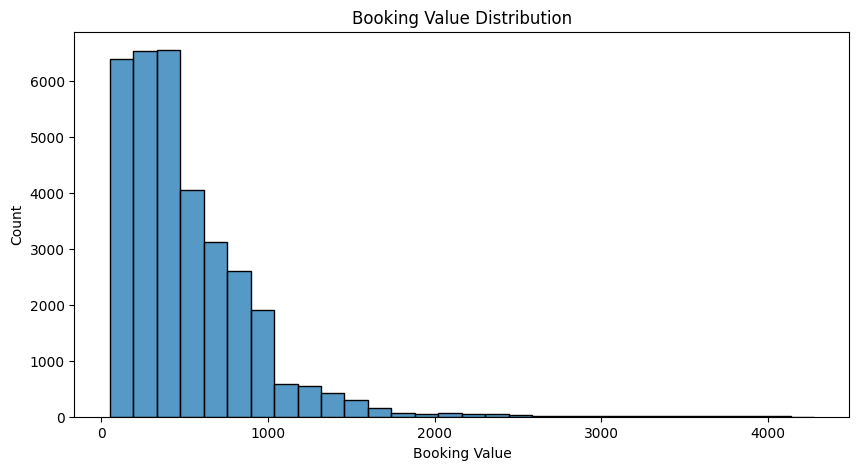

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Booking Value'].dropna(),
    bins=30
)
plt.title("Booking Value Distribution")
plt.xlabel("Booking Value")
plt.show()

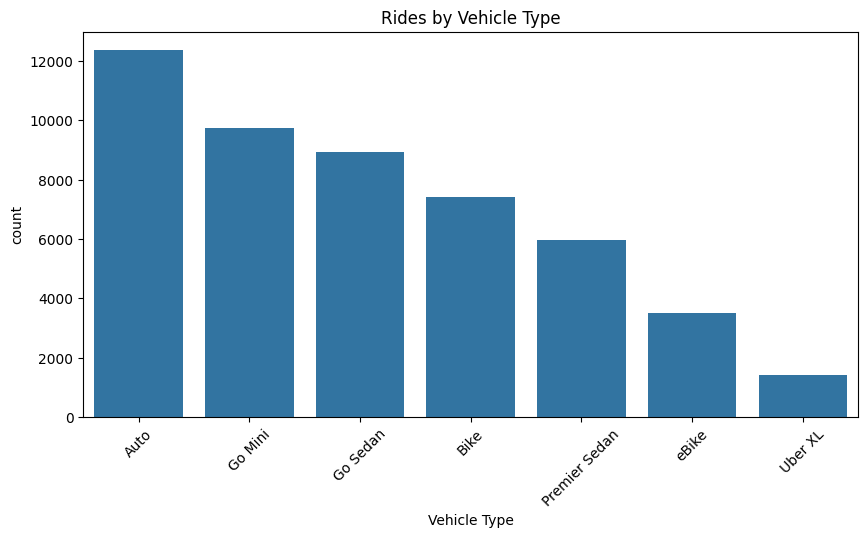

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Vehicle Type',
    data=df,
    order=df['Vehicle Type'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Rides by Vehicle Type")
plt.show()

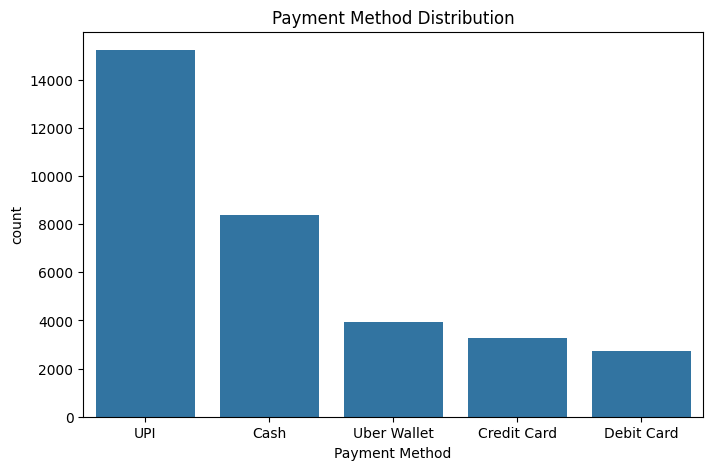

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Payment Method',
    data=df,
    order=df['Payment Method'].value_counts().index
)
plt.title("Payment Method Distribution")
plt.show()

## Hourly Ride Demand Analysis

This analysis identifies peak booking hours and ride demand patterns throughout the day.

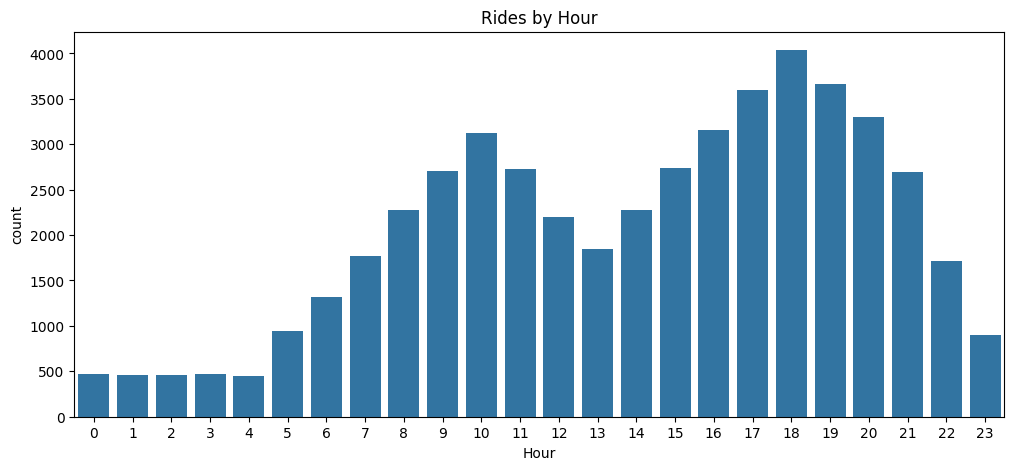

In [15]:
plt.figure(figsize=(12,5))
sns.countplot(
    x='Hour',
    data=df
)
plt.title("Rides by Hour")
plt.show()

## Weekly Ride Demand Analysis
This analysis evaluates booking demand trends across weekdays.

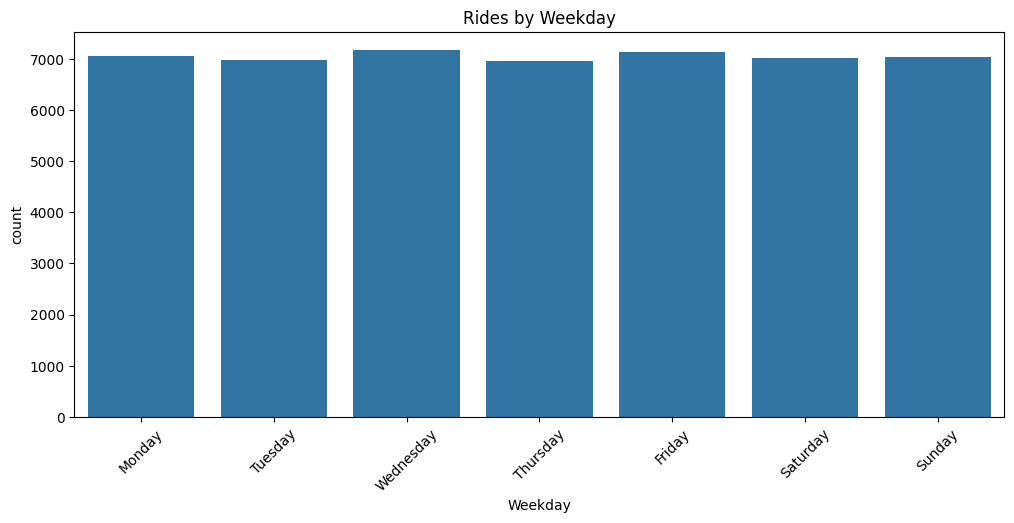

In [16]:
plt.figure(figsize=(12,5))
sns.countplot(
    x='Weekday',
    data=df,
    order=[
        'Monday','Tuesday','Wednesday',
        'Thursday','Friday','Saturday','Sunday'
    ]
)
plt.title("Rides by Weekday")
plt.xticks(rotation=45)
plt.show()

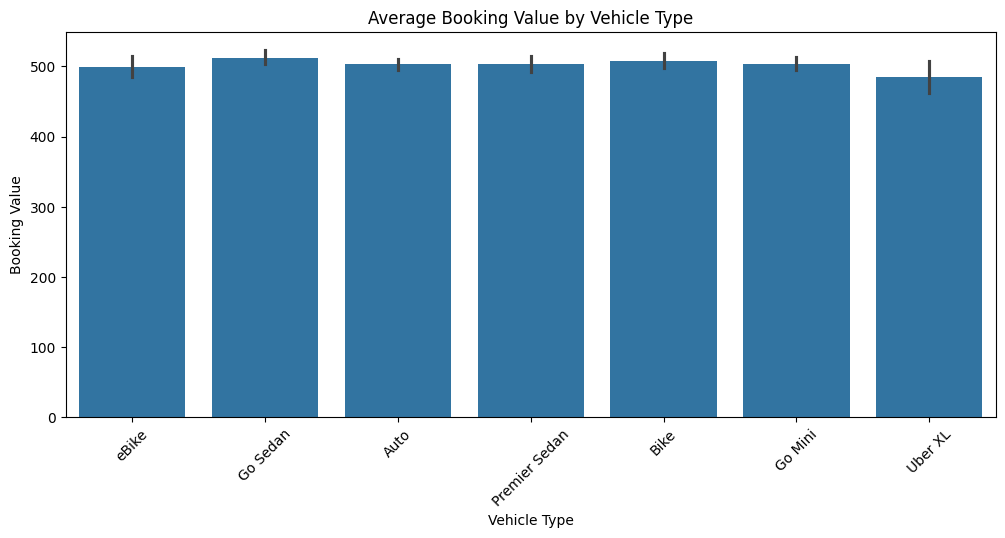

In [17]:
plt.figure(figsize=(12,5))

sns.barplot(
    x='Vehicle Type',
    y='Booking Value',
    data=df
)

plt.title("Average Booking Value by Vehicle Type")
plt.xticks(rotation=45)
plt.show()

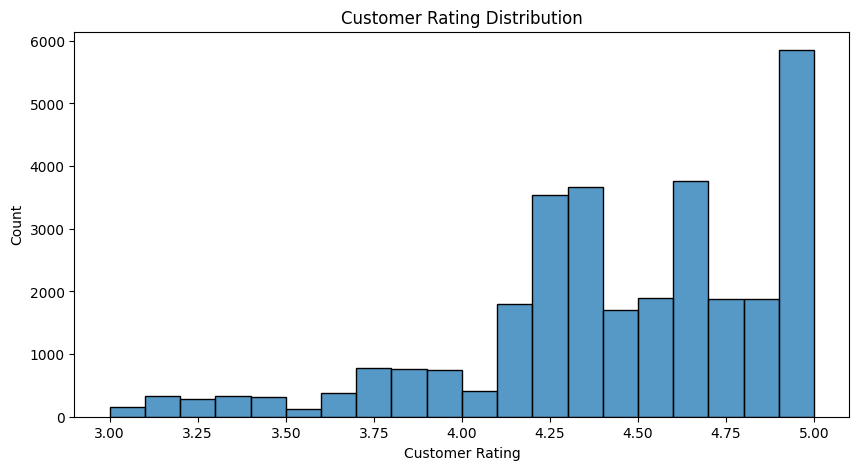

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Customer Rating'].dropna(),
    bins=20
)
plt.title("Customer Rating Distribution")
plt.show()

## Correlation Analysis

A heatmap is generated to identify relationships between numerical variables in the dataset.

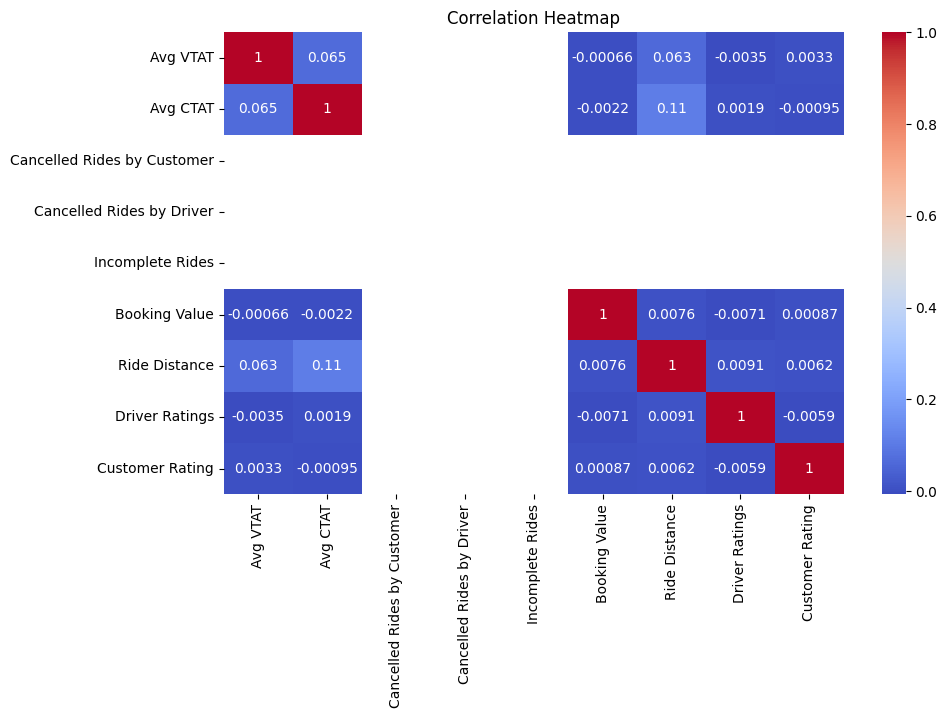

In [19]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

## Booking Status Simplification

Booking statuses are simplified into binary classes for machine learning:
- Completed
- Cancelled

In [23]:
df_ml = df.copy()
df_ml['Booking Status'] = df_ml['Booking Status'].replace({
    'Cancelled by Driver': 'Cancelled',
    'Cancelled by Customer': 'Cancelled',
    'No Driver Found': 'Cancelled',
    'Incomplete': 'Cancelled'
})
df_ml['Booking Status'].value_counts()

,count
Booking Status,
Completed,30595
Cancelled,18699


## Feature Selection

Relevant business and operational features are selected for machine learning model training.

In [24]:
selected_columns = [
    'Vehicle Type',
    'Pickup Location',
    'Drop Location',
    'Booking Value',
    'Ride Distance',
    'Payment Method',
    'Driver Ratings',
    'Customer Rating',
    'Hour',
    'Weekday',
    'Booking Status'
]
ml_df = df_ml[selected_columns]
ml_df.head()

,Vehicle Type,Pickup Location,Drop Location,Booking Value,Ride Distance,Payment Method,Driver Ratings,Customer Rating,Hour,Weekday,Booking Status
0,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,12,Saturday,Cancelled
1,Go Sedan,Shastri Nagar,Gurgaon Sector 56,237.0,5.73,UPI,NaN,NaN,18,Friday,Cancelled
2,Auto,Khandsa,Malviya Nagar,627.0,13.58,Debit Card,4.9,4.9,8,Friday,Completed
3,Premier Sedan,Central Secretariat,Inderlok,416.0,34.02,UPI,4.6,5.0,17,Monday,Completed
4,Bike,Ghitorni Village,Khan Market,737.0,48.21,UPI,4.1,4.3,22,Monday,Completed


In [25]:
# Separate 'Completed' and 'Cancelled' bookings before handling NaNs
completed_bookings = ml_df[ml_df['Booking Status'] == 'Completed'].copy()
cancelled_bookings = ml_df[ml_df['Booking Status'] == 'Cancelled'].copy()

# Columns that are typically NaN for cancelled rides but useful for training
numerical_cols_for_imputation = [
    'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating'
]

# For 'Cancelled' bookings, impute NaNs with 0 in numerical columns
# and 'Unknown' for 'Payment Method'
for col in numerical_cols_for_imputation:
    cancelled_bookings[col] = cancelled_bookings[col].fillna(0)
cancelled_bookings['Payment Method'] = cancelled_bookings['Payment Method'].fillna('Unknown')

# For 'Completed' bookings, drop rows with any remaining NaNs
# This ensures genuine missing data for completed rides is handled
completed_bookings = completed_bookings.dropna()

# Concatenate the processed dataframes back
ml_df = pd.concat([completed_bookings, cancelled_bookings])

print("Remaining Rows:", ml_df.shape[0])

Remaining Rows: 30594


In [26]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
categorical_cols = [
    'Vehicle Type',
    'Pickup Location',
    'Drop Location',
    'Payment Method',
    'Weekday',
    'Booking Status'
]
for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col])
    label_encoders[col] = le

print("Encoding completed")

Encoding completed


## Feature and Target Definition

The dataset is split into:
- input features (X)
- target variable (y)

In [27]:
X = ml_df.drop('Booking Status', axis=1)
y = ml_df['Booking Status']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (30594, 10)
Target Shape: (30594,)


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Train-Test Split Completed")

Train-Test Split Completed


## Logistic Regression Model

A Logistic Regression model is trained as the baseline classification algorithm for predicting ride booking completion and cancellation.

In [41]:
selected_columns = [
    'Vehicle Type',
    'Pickup Location',
    'Drop Location',
    'Booking Value',
    'Ride Distance',
    'Payment Method',
    'Driver Ratings',
    'Customer Rating',
    'Hour',
    'Weekday',
    'Booking Status'
]
ml_df = df_ml[selected_columns].copy()

In [42]:
ml_df['Booking Value'] = ml_df['Booking Value'].fillna(
    ml_df['Booking Value'].median()
)

ml_df['Ride Distance'] = ml_df['Ride Distance'].fillna(
    ml_df['Ride Distance'].median()
)

ml_df['Driver Ratings'] = ml_df['Driver Ratings'].fillna(
    ml_df['Driver Ratings'].median()
)

ml_df['Customer Rating'] = ml_df['Customer Rating'].fillna(
    ml_df['Customer Rating'].median()
)
ml_df['Payment Method'] = ml_df['Payment Method'].fillna("Unknown")

In [43]:
ml_df['Booking Status'].value_counts()

,count
Booking Status,
Completed,30595
Cancelled,18699


In [44]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = [
    'Vehicle Type',
    'Pickup Location',
    'Drop Location',
    'Payment Method',
    'Weekday',
    'Booking Status'
]

for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col])
    label_encoders[col] = le

In [46]:
from sklearn.model_selection import train_test_split
X = ml_df.drop('Booking Status', axis=1)
y = ml_df['Booking Status']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_accuracy = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy:", log_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.9070899685566487

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.87      0.88      3753
           1       0.92      0.93      0.93      6106

    accuracy                           0.91      9859
   macro avg       0.90      0.90      0.90      9859
weighted avg       0.91      0.91      0.91      9859



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Random Forest Classifier

A Random Forest classifier is trained to capture complex non-linear operational patterns in ride booking and cancellation behavior.

In [48]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9984785475200325

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3753
           1       1.00      1.00      1.00      6106

    accuracy                           1.00      9859
   macro avg       1.00      1.00      1.00      9859
weighted avg       1.00      1.00      1.00      9859



In [49]:
!pip install xgboost

## XGBoost Classifier

An XGBoost classifier is trained for advanced gradient boosting-based cancellation prediction and operational intelligence.

In [50]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9983771173547012

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3753
           1       1.00      1.00      1.00      6106

    accuracy                           1.00      9859
   macro avg       1.00      1.00      1.00      9859
weighted avg       1.00      1.00      1.00      9859



## Machine Learning Model Comparison

The performance of multiple machine learning models is compared to identify the most effective cancellation prediction approach.

In [51]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.907090
1,Random Forest,0.998479
2,XGBoost,0.998377


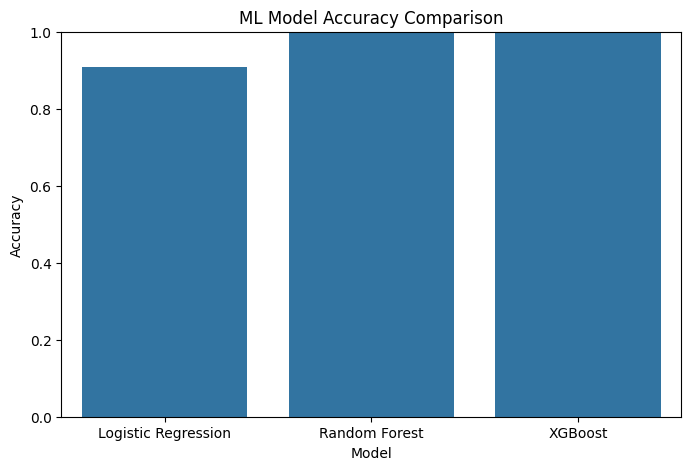

In [52]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_results
)

plt.title("ML Model Accuracy Comparison")

plt.ylim(0,1)

plt.show()

## Confusion Matrix

A confusion matrix is used to evaluate how accurately the machine learning model classifies completed and cancelled rides.

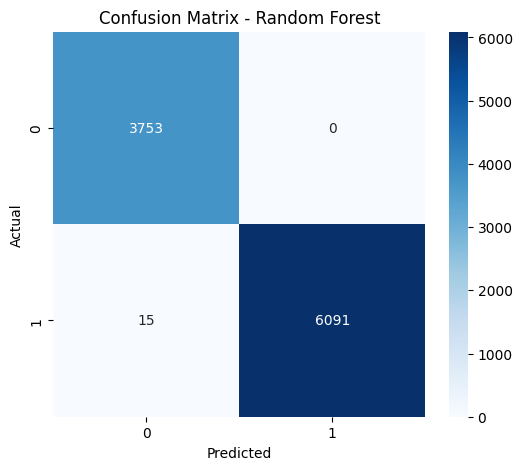

In [53]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance Analysis

Feature importance identifies the operational variables that most strongly influence ride completion and cancellation prediction.

In [54]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
5,Payment Method,0.381646
7,Customer Rating,0.232280
4,Ride Distance,0.181108
6,Driver Ratings,0.139053
3,Booking Value,0.058369
2,Drop Location,0.002191
1,Pickup Location,0.002072
8,Hour,0.001537
9,Weekday,0.000884
0,Vehicle Type,0.000861


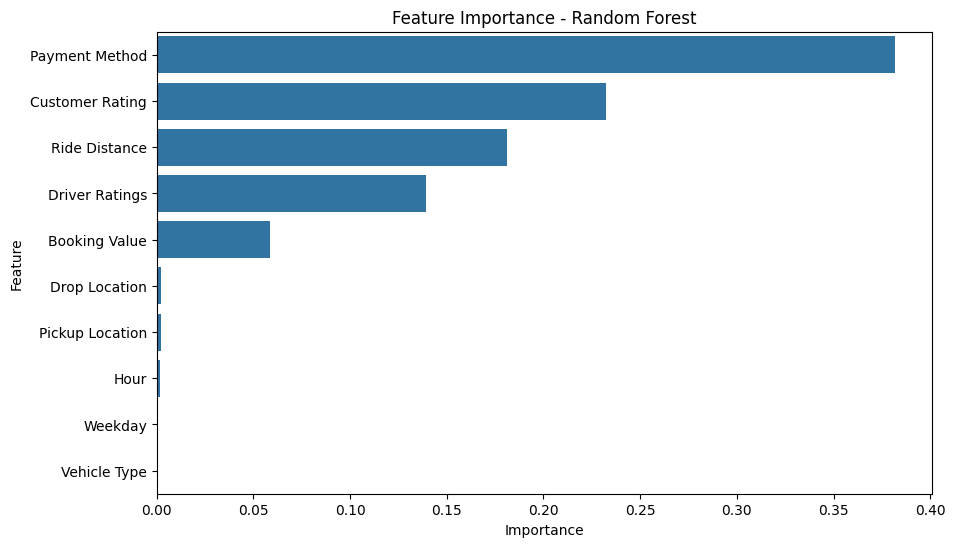

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

## Daily Ride Demand Trend

Daily ride booking volume is analyzed to identify temporal demand patterns and forecasting opportunities.

In [57]:
daily_rides = df.groupby('Date').size()
daily_rides.head()

,0
Date,
2024-01-01,137
2024-01-02,128
2024-01-03,145
2024-01-04,126
2024-01-05,149


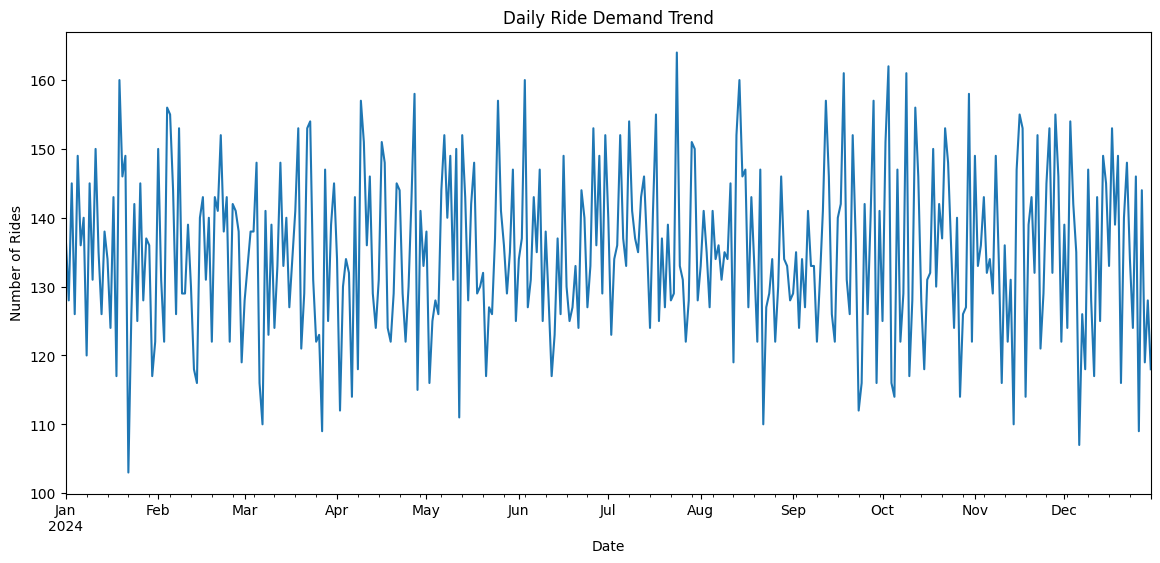

In [58]:
plt.figure(figsize=(14,6))

daily_rides.plot()

plt.title("Daily Ride Demand Trend")

plt.xlabel("Date")
plt.ylabel("Number of Rides")

plt.show()

## Demand Smoothing using Moving Average

A moving average is applied to smooth ride demand fluctuations and highlight long-term demand patterns.

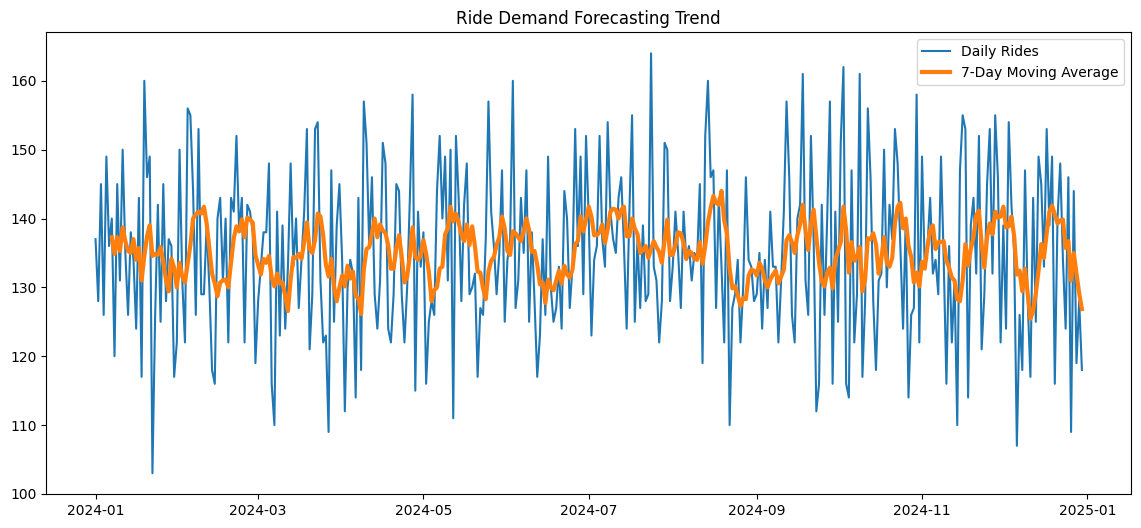

In [59]:
rolling_avg = daily_rides.rolling(window=7).mean()

plt.figure(figsize=(14,6))

plt.plot(daily_rides, label='Daily Rides')

plt.plot(
    rolling_avg,
    label='7-Day Moving Average',
    linewidth=3
)

plt.legend()

plt.title("Ride Demand Forecasting Trend")

plt.show()

## Basic Demand Forecasting

Linear regression is applied to estimate future ride demand trends.

In [60]:
from sklearn.linear_model import LinearRegression
forecast_df = daily_rides.reset_index()
forecast_df.columns = ['Date', 'Rides']
forecast_df['Day_Number'] = range(len(forecast_df))
X_forecast = forecast_df[['Day_Number']]
y_forecast = forecast_df['Rides']
forecast_model = LinearRegression()
forecast_model.fit(X_forecast, y_forecast)
forecast_df['Predicted_Rides'] = forecast_model.predict(X_forecast)
forecast_df.head()

,Date,Rides,Day_Number,Predicted_Rides
0,2024-01-01,137,0,134.959263
1,2024-01-02,128,1,134.959773
2,2024-01-03,145,2,134.960283
3,2024-01-04,126,3,134.960793
4,2024-01-05,149,4,134.961303


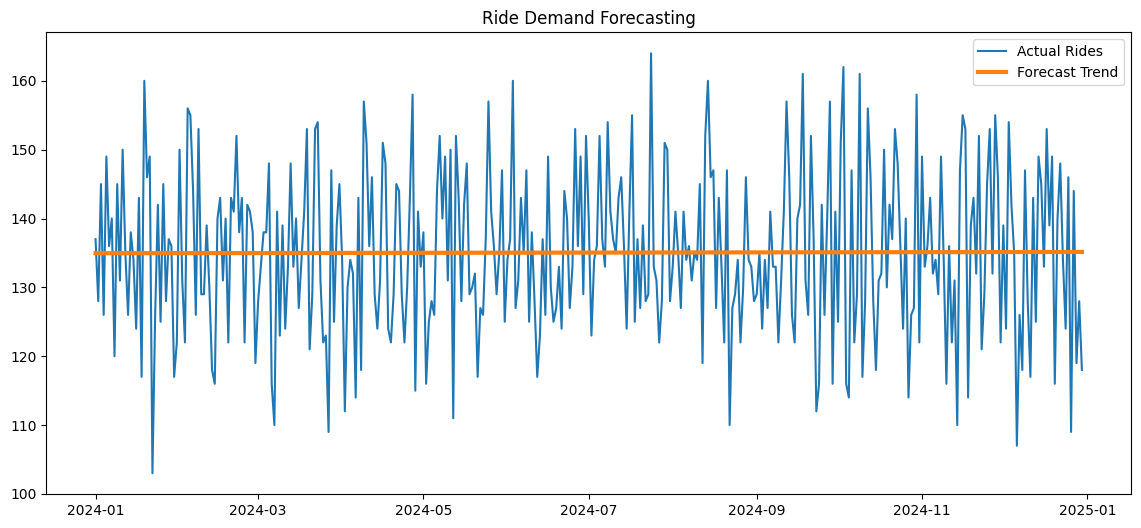

In [61]:
plt.figure(figsize=(14,6))

plt.plot(
    forecast_df['Date'],
    forecast_df['Rides'],
    label='Actual Rides'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Predicted_Rides'],
    label='Forecast Trend',
    linewidth=3
)

plt.legend()

plt.title("Ride Demand Forecasting")

plt.show()